In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier')

from Tokenizer.UniTok import UniTokTokenizer
from Tiler import Tiler
from utils_benchmark import load_all_images
from Tokenizer.UniTok import TOKENIZER, TOKENIZER_PATH

/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
tokenizer = UniTokTokenizer(ckpt_path=TOKENIZER_PATH, device='cuda', image_size=256)
tiler = Tiler(tile_size=384, pad_value=-1.0, tile_resize=256)
images, _, image_paths = load_all_images('../assets/original')

Linear scaling ratio: 256/384 = 0.667
Pixel per tile ratio: 256²/384² = 0.444
Pixel reduction: 55.6% fewer pixels per tile (downsampling)
Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: mri_human_brain.png
Loaded: physics1.png
Loaded: physics2.png
Loaded: tcp_1.png


Original image: 3×2100×1400
Downsampling to: 1400×933 (ratio: 0.667)
Padding to: 1536×1024
Creating 6×4 = 24 tiles of 256×256
Showing 6×4 = 24 tiles


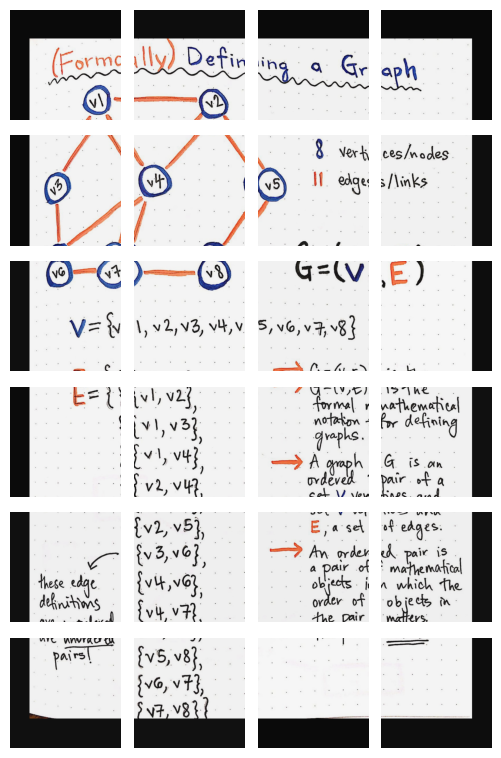

In [7]:
image = images[0]
res = tiler(image)
tiler.show_tiles(res['tiles'], res['metadata'])

In [8]:
image_tensor = tokenizer.preprocess(image).squeeze(0)
image_tiled = tiler(image_tensor)['tiles'].to('cuda')

Original image: 3×2100×1400
Downsampling to: 1400×933 (ratio: 0.667)
Padding to: 1536×1024
Creating 6×4 = 24 tiles of 256×256


In [9]:
import torch

with torch.no_grad():
    code_idx = tokenizer.model.img_to_idx(image_tiled)

/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/torch/utils/checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/torch/utils/checkpoint.py:61: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [15]:
tile = code_idx[0:1]

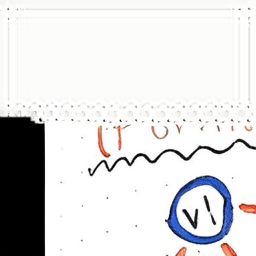

In [34]:
with torch.no_grad():
    # Get the tokenized image codes
    code_idx = tokenizer.model.img_to_idx(image_tiled)  # Shape: [24, 8, 256]
    
    # Get first tile
    tile = code_idx[0:1]  # Shape: [1, 8, 256]
    
    # Get tokens from all 8 channels at spatial position 1
    replacement_tokens = tile[0, :, 110]  # Shape: [8] - tensor([358, 2319, 2809, 3263, 3777, 2188, 3311, 2649])
    
    # Calculate half point for spatial dimension
    spatial_length = tile.shape[-1]  # 256
    half_length = spatial_length // 2  # 128
    
    # Create modified tile
    modified_tile = tile.clone()
    
    # Replace first half of all channels with the replacement tokens
    # Broadcast the [8] tokens across the first half spatial positions
    modified_tile[0, :, :half_length] = replacement_tokens.unsqueeze(-1).expand(-1, half_length)
    
    # Reconstruct the image from the modified tokens
    reconstructed_image = tokenizer.model.idx_to_img(modified_tile)

    reconstructed_image = tokenizer.postprocess(reconstructed_image)
    reconstructed_image.show()

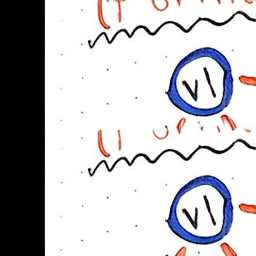

In [28]:
with torch.no_grad():
    # Get the tokenized image codes
    code_idx = tokenizer.model.img_to_idx(image_tiled)  # Shape: [24, 8, 256]
    
    # Get first tile
    tile = code_idx[0:1]  # Shape: [1, 8, 256]
    
    # Calculate half point for spatial dimension
    spatial_length = tile.shape[-1]  # 256
    half_length = spatial_length // 2  # 128
    
    # Create modified tile
    modified_tile = tile.clone()
    
    # Duplicate second half to first half for all channels
    modified_tile[0, :, :half_length] = modified_tile[0, :, half_length:]
    
    # Reconstruct the image from the modified tokens
    reconstructed_image = tokenizer.model.idx_to_img(modified_tile)

    reconstructed_image = tokenizer.postprocess(reconstructed_image)
    reconstructed_image.show()  